# Flood Risk & Building Claims Analysis  
**Research Question:** Can we use flood exposure predict building claim losses?  

### Baseline Models
- **Model A:** Linear Regression → predict `log1p(amountPaidOnBuildingClaim)`
- **Model B:** Logistic Regression → predict high/low loss (above/below median)
- **Model C:** Random Forest Regressor → same target as A
- **Model D:** Random Forest Classifier → same target as B

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)

Libraries loaded successfully.


In [14]:
# define file paths
paths = {
    'county_claims': '../data/processed/selected_county_claims.csv',
    'profiling_table': '../output/profiling_table.csv'
}
# paths['output_graph1'] = '../output/


In [12]:
# import data
df = pd.read_csv(paths['county_claims'])

/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_10498/1829000608.py:2: DtypeWarning: Columns (0: causeOfDamage) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(paths['county_claims'])


In [13]:
df.head()

,agricultureStructureIndicator,asOfDate,basementEnclosureCrawlspaceType,policyCount,crsClassificationCode,dateOfLoss,elevatedBuildingIndicator,elevationCertificateIndicator,elevationDifference,baseFloodElevation,...,rentalPropertyIndicator,state,reportedCity,reportedZipCode,countyCode,censusTract,censusBlockGroupFips,latitude,longitude,id
0,False,2026-02-11 00:00:00+00:00,NaN,1,NaN,1996-09-05,False,NaN,NaN,NaN,...,False,NC,Currently Unavailable,27810.00,37013,37013930700.00,370139307001.00,35.50,-76.60,069b717f-4be7-4a39-b86c-856ed210869c
1,False,2026-02-11 00:00:00+00:00,NaN,1,NaN,1998-08-26,False,NaN,NaN,NaN,...,False,NC,Currently Unavailable,27810.00,37013,37013930100.00,370139301005.00,35.50,-76.60,a094b0f5-7e81-4606-916d-e1427026b4e9
2,False,2026-02-11 00:00:00+00:00,NaN,1,NaN,1999-09-16,False,NaN,3.00,119.50,...,False,NC,Currently Unavailable,27801.00,37065,37065020400.00,370650204004.00,35.90,-77.80,d8fc0653-9392-49a8-81ba-19f4272df92a
3,False,2026-02-11 00:00:00+00:00,NaN,1,NaN,2016-10-09,True,NaN,-2.00,35.00,...,False,NC,Currently Unavailable,28501.00,37107,37107010200.00,371070102002.00,35.30,-77.60,6d61a117-df44-4a51-b940-cdffe5bf480c
4,False,2026-02-11 00:00:00+00:00,NaN,1,NaN,2011-08-27,False,NaN,NaN,NaN,...,False,NC,Currently Unavailable,27810.00,37013,37013930100.00,370139301006.00,35.50,-76.60,282c05ff-a5cc-4cdf-a9c9-5fe42c2737cb


In [21]:
# data inspection
print(f'Raw data shape: {df.shape}')

profile_table = pd.DataFrame({
    "col_name": df.columns,
    "dtype": df.dtypes,
    "n_missing": [df[col].isna().sum() for col in df.columns],
    "missing_rate": [round(df[col].isna().mean()*100, 2) for col in df.columns],
    "is_unique": df.columns.duplicated(),
    "n_unique": [df[col].nunique() for col in df.columns],
    "sample_values": [list(df[col].unique()[0:3]) for col in df.columns]
}).set_index("col_name")
profile_table.to_csv(paths['profiling_table'])
profile_table

Raw data shape: (13712, 73)


,dtype,n_missing,missing_rate,is_unique,n_unique,sample_values
col_name,,,,,,
agricultureStructureIndicator,bool,0,0.00,False,2,"[False, True]"
asOfDate,str,0,0.00,False,1,[2026-02-11 00:00:00+00:00]
basementEnclosureCrawlspaceType,float64,11138,81.23,False,4,"[nan, 2.0, 0.0]"
policyCount,int64,0,0.00,False,4,"[1, 8, 2]"
crsClassificationCode,float64,13133,95.78,False,3,"[nan, 7.0, 8.0]"
...,...,...,...,...,...,...
censusTract,float64,551,4.02,False,116,"[37013930700.0, 37013930100.0, 37065020400.0]"
censusBlockGroupFips,float64,551,4.02,False,285,"[370139307001.0, 370139301005.0, 370650204004.0]"
latitude,float64,0,0.00,False,17,"[35.5, 35.9, 35.3]"


In [24]:
# find high missing rate columns
high_missing_cols = profile_table[profile_table['missing_rate'] > 50].index.tolist()
print(f"Columns with >50% missing values: {len(high_missing_cols)}")

unique_cols = profile_table[profile_table['is_unique'] == True].index.tolist()
print(f"Columns with unique values: {len(unique_cols)}")

Columns with >50% missing values: 18
Columns with unique values: 0


In [25]:
for col in df.columns:
    print(col)
    

agricultureStructureIndicator
asOfDate
basementEnclosureCrawlspaceType
policyCount
crsClassificationCode
dateOfLoss
elevatedBuildingIndicator
elevationCertificateIndicator
elevationDifference
baseFloodElevation
ratedFloodZone
houseWorship
locationOfContents
lowestAdjacentGrade
lowestFloorElevation
numberOfFloorsInTheInsuredBuilding
nonProfitIndicator
obstructionType
occupancyType
originalConstructionDate
originalNBDate
amountPaidOnBuildingClaim
amountPaidOnContentsClaim
amountPaidOnIncreasedCostOfComplianceClaim
postFIRMConstructionIndicator
rateMethod
smallBusinessIndicatorBuilding
totalBuildingInsuranceCoverage
totalContentsInsuranceCoverage
yearOfLoss
primaryResidenceIndicator
buildingDamageAmount
buildingDeductibleCode
netBuildingPaymentAmount
buildingPropertyValue
causeOfDamage
condominiumCoverageTypeCode
contentsDamageAmount
contentsDeductibleCode
netContentsPaymentAmount
contentsPropertyValue
disasterAssistanceCoverageRequired
eventDesignationNumber
ficoNumber
floodCharacteristi

### Data Inspection and Cleaning & Feature Engineering

| Issue | Decision |
|-------|----------|
| Null claim amounts (13.4%) | Drop — no Y value means unusable |
| Y variable right-skewed | log1p transform |
| Bad construction dates (e.g. 1492) | Clip to 1800–2025 |
| ratedFloodZone 26 categories | Simplify: High/Moderate/Low/Possible |
| Unknown flood zone (521 rows) | Drop — not a real risk category |
| waterDepth nulls | Fill with median, clip at P99=49ft |
| Rare flood events (<20 samples) | Merge into 'Other' |

In [8]:
df = df_raw.copy()

# 1. Drop rows without claim amount
df = df.dropna(subset=['amountPaidOnBuildingClaim'])
print(f'After dropping null claims: {len(df)} rows')

# 2. Parse year_built, compute building_age
df['year_built'] = pd.to_datetime(df['originalConstructionDate'], errors='coerce').dt.year
df['year_built'] = df['year_built'].clip(lower=1800, upper=2025)
df['building_age'] = df['yearOfLoss'] - df['year_built']
df['building_age'] = df['building_age'].clip(lower=0)

# 3. Simplify flood zone
def simplify_flood_zone(zone):
    if pd.isna(zone):
        return 'Unknown'
    zone = str(zone).strip().upper()
    if zone.startswith('V') or zone.startswith('A') or zone.startswith('AR'):
        return 'High'
    elif zone == 'D':
        return 'Possible'
    elif zone in ['B', 'X']:
        return 'Moderate'
    elif zone == 'C':
        return 'Low'
    else:
        return 'Unknown'

df['flood_zone_simple'] = df['ratedFloodZone'].apply(simplify_flood_zone)

# Drop Unknown zone rows
df = df[df['flood_zone_simple'] != 'Unknown'].reset_index(drop=True)
print(f'After dropping Unknown zone: {len(df)} rows')
print('Flood zone distribution:')
print(df['flood_zone_simple'].value_counts())

# 4. Fill waterDepth nulls, clip at P99
median_depth = df['waterDepth'].median()
df['waterDepth'] = df['waterDepth'].fillna(median_depth)
df['waterDepth'] = df['waterDepth'].clip(upper=49)
print(f'\nwaterDepth median: {median_depth:.1f} ft, clipped at 49 ft')

# 5. Merge rare flood events (<20 samples) into 'Other'
df['floodEvent'] = df['floodEvent'].fillna('Unknown')
event_counts = df['floodEvent'].value_counts()
df['floodEvent'] = df['floodEvent'].apply(
    lambda x: x if event_counts[x] >= 20 else 'Other'
)
print('\nFlood event distribution after merging small samples:')
print(df['floodEvent'].value_counts())

# 6. Encode binary/indicator variables
df['is_residential']   = df['occupancyType'].isin([1,2,11,12,13,14]).astype(int)
df['elevated']         = df['elevatedBuildingIndicator'].astype(int)
df['post_firm']        = df['postFIRMConstructionIndicator'].astype(int)
df['primary_residence']= df['primaryResidenceIndicator'].astype(int)

# 7. Dummy variables
zone_dummies   = pd.get_dummies(df['flood_zone_simple'], prefix='zone',   drop_first=True)
county_dummies = pd.get_dummies(df['countyCode'],        prefix='county', drop_first=True)
event_dummies  = pd.get_dummies(df['floodEvent'],        prefix='event',  drop_first=True)

print('\nCleaning complete.')

After dropping null claims: 11874 rows
After dropping Unknown zone: 11353 rows
Flood zone distribution:
flood_zone_simple
High        10141
Moderate     1107
Low           105
Name: count, dtype: int64

waterDepth median: 1.0 ft, clipped at 49 ft

Flood event distribution after merging small samples:
floodEvent
Hurricane Florence        1817
Hurricane Floyd           1679
Hurricane Irene           1482
Hurricane Matthew         1452
Hurricane Dennis          1048
Hurricane Fran            1015
Hurricane Bonnie           903
Unknown                    637
Hurricane Isabel           614
Hurricane Bertha           369
Tropical Storm Ophelia      97
Other                       94
Hurricane Debby             58
Tropical Storm Ernesto      47
Hurricane Eta               41
Name: count, dtype: int64

Cleaning complete.


## Step 4: Assemble Feature Matrix X and Targets y

In [9]:
continuous_features = [
    'waterDepth',
    'building_age',
    'totalBuildingInsuranceCoverage',
]

binary_features = [
    'elevated',
    'post_firm',
    'is_residential',
    'primary_residence',
]

df = df.reset_index(drop=True)

X = pd.concat([
    df[continuous_features + binary_features].reset_index(drop=True),
    zone_dummies.reset_index(drop=True),
    county_dummies.reset_index(drop=True),
    event_dummies.reset_index(drop=True)
], axis=1)

# Drop rows with any remaining nulls
mask = X.notna().all(axis=1)
X = X[mask].reset_index(drop=True)
df_clean = df[mask].reset_index(drop=True)

print(f'Final dataset: {len(X)} rows, {X.shape[1]} features')
print(f'\nFeature columns:')
for col in X.columns:
    print(f'  {col}')

Final dataset: 11353 rows, 27 features

Feature columns:
  waterDepth
  building_age
  totalBuildingInsuranceCoverage
  elevated
  post_firm
  is_residential
  primary_residence
  zone_Low
  zone_Moderate
  county_37065
  county_37107
  county_37155
  county_37191
  event_Hurricane Bonnie
  event_Hurricane Debby
  event_Hurricane Dennis
  event_Hurricane Eta
  event_Hurricane Florence
  event_Hurricane Floyd
  event_Hurricane Fran
  event_Hurricane Irene
  event_Hurricane Isabel
  event_Hurricane Matthew
  event_Other
  event_Tropical Storm Ernesto
  event_Tropical Storm Ophelia
  event_Unknown


In [10]:
# Model A target: log1p(claim amount)
y_A = np.log1p(df_clean['amountPaidOnBuildingClaim'])

# Model B target: above median = high loss (1), below = low loss (0)
median_claim = df_clean['amountPaidOnBuildingClaim'].median()
y_B = (df_clean['amountPaidOnBuildingClaim'] > median_claim).astype(int)

print(f'Median threshold: ${median_claim:,.0f}')
print(f'\nModel A (log claim amount):')
print(f'  Mean: {y_A.mean():.2f}, Std: {y_A.std():.2f}, Range: [{y_A.min():.1f}, {y_A.max():.1f}]')
print(f'\nModel B (high/low loss):')
print(f'  High loss (1): {y_B.sum()} ({y_B.mean()*100:.1f}%)')
print(f'  Low loss  (0): {(y_B==0).sum()} ({(y_B==0).mean()*100:.1f}%)')

Median threshold: $8,743

Model A (log claim amount):
  Mean: 8.89, Std: 1.98, Range: [0.0, 13.1]

Model B (high/low loss):
  High loss (1): 5676 (50.0%)
  Low loss  (0): 5677 (50.0%)


## Step 5: EDA

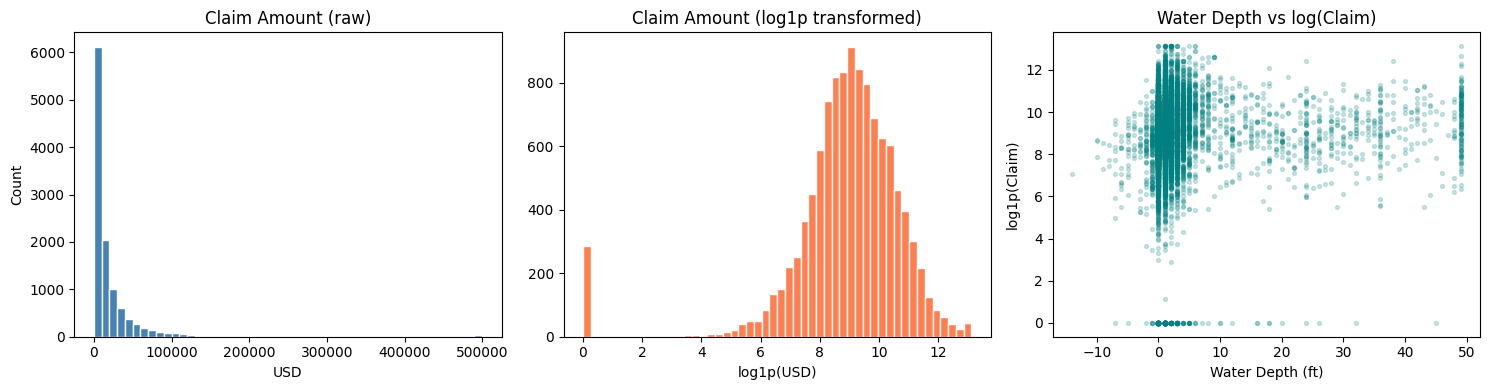

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_clean['amountPaidOnBuildingClaim'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Claim Amount (raw)'); axes[0].set_xlabel('USD'); axes[0].set_ylabel('Count')

axes[1].hist(y_A, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Claim Amount (log1p transformed)'); axes[1].set_xlabel('log1p(USD)')

axes[2].scatter(df_clean['waterDepth'], y_A, alpha=0.2, s=8, color='teal')
axes[2].set_title('Water Depth vs log(Claim)')
axes[2].set_xlabel('Water Depth (ft)'); axes[2].set_ylabel('log1p(Claim)')

plt.tight_layout(); plt.show()

### Violin: Original claim amount by Flood Zone
Raw claim distribution (clipped at 99th percentile to show bulk).

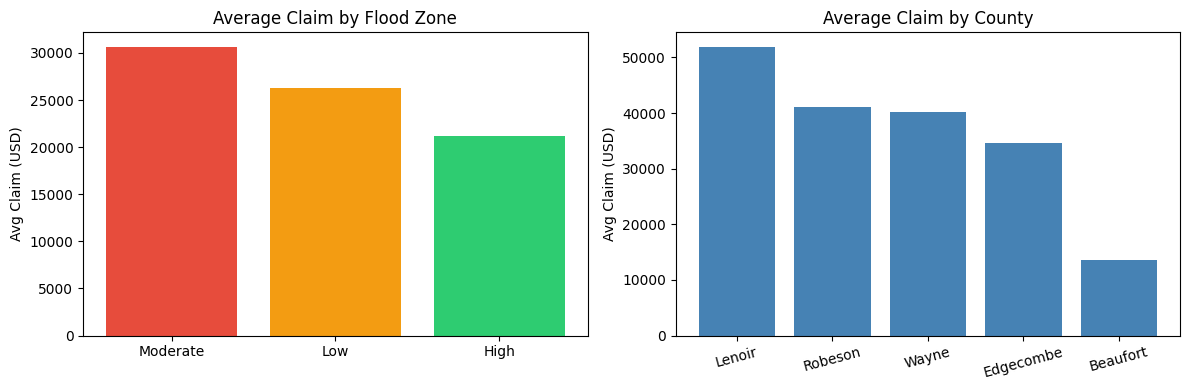

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

avg_by_zone = df_clean.groupby('flood_zone_simple')['amountPaidOnBuildingClaim'].mean().sort_values(ascending=False)
axes[0].bar(avg_by_zone.index, avg_by_zone.values, color=['#e74c3c','#f39c12','#2ecc71','#95a5a6'])
axes[0].set_title('Average Claim by Flood Zone'); axes[0].set_ylabel('Avg Claim (USD)')

county_names = {37013:'Beaufort',37065:'Edgecombe',37107:'Lenoir',37155:'Robeson',37191:'Wayne'}
df_clean['county_name'] = df_clean['countyCode'].map(county_names)
avg_by_county = df_clean.groupby('county_name')['amountPaidOnBuildingClaim'].mean().sort_values(ascending=False)
axes[1].bar(avg_by_county.index, avg_by_county.values, color='steelblue')
axes[1].set_title('Average Claim by County'); axes[1].set_ylabel('Avg Claim (USD)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

In [31]:
# analyze claim amount distribution by flood zone and thresholds (above)
thresholds = [25000, 50000, 100000, 250000]
zones = sorted(df_clean['flood_zone_simple'].unique())
rows = []
for t in thresholds:
    for z in zones:
        s = df_clean.loc[df_clean['flood_zone_simple'] == z, col]
        total_n = len(s)
        grp = s[s > t]
        count = int(grp.count())
        pct_count = (count / total_n * 100) if total_n > 0 else 0.0
        pct_amount = (grp.sum() / s.sum() * 100) if s.sum() > 0 else 0.0
        avg_amount = float(grp.mean()) if count > 0 else float('nan')
        rows.append({
            'flood_zone': z,
            'threshold': t,
            'count': count,
            'pct_count_within_zone': round(pct_count, 2),
            'pct_amount_within_zone': round(pct_amount, 2),
            'avg_amount_within_group': round(avg_amount, 2) if not np.isnan(avg_amount) else np.nan
        })

df_thresholds = pd.DataFrame(rows).set_index(['flood_zone', 'threshold']).sort_index()
df_thresholds

count  pct_count_within_zone  pct_amount_within_zone  \
flood_zone threshold                                                         
High       25000       2210                  21.79                   71.91   
           50000        975                   9.61                   51.57   
           100000       330                   3.25                   30.78   
           250000        59                   0.58                   11.59   
Low        25000         22                  20.95                   76.33   
           50000          8                   7.62                   57.98   
           100000         5                   4.76                   50.66   
           250000         2                   1.90                   36.21   
Moderate   25000        346                  31.26                   79.56   
           50000        176                  15.90                   60.70   
           100000        65                   5.87                   37.17   
           250000        15                   1.36                   14.00   

                      avg_amount_within_group  
flood_zone threshold                           
High       25000                     70048.79  
           50000                    113877.98  
           100000                   200779.46  
           250000                   422769.38  
Low        25000                     95811.18  
           50000                    200120.21  
           100000                   279769.28  
           250000                   500000.00  
Moderate   25000                     78042.24  
           50000                    117053.53  
           100000                   194072.61  
           250000                   316843.11

/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_26015/3507231696.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


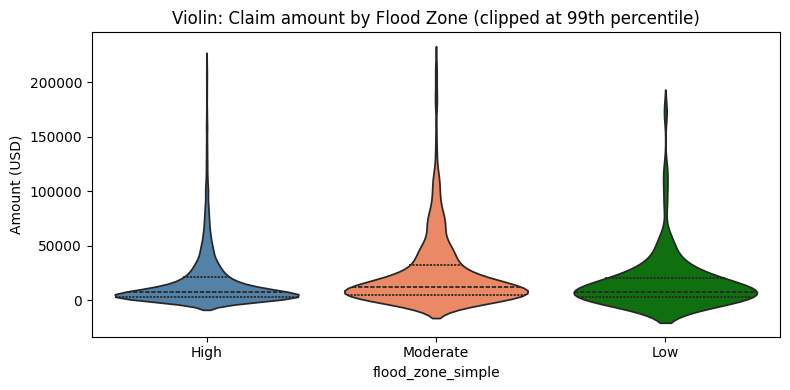

In [22]:
# Violin plot for raw claim amounts (clipped at 99th percentile)
col = 'amountPaidOnBuildingClaim'
p99 = df_clean[col].quantile(0.99)
fig, ax = plt.subplots(figsize=(8,4))
sns.violinplot(
    x='flood_zone_simple',
    y=col,
    data=df_clean[df_clean[col] <= p99],
    inner='quartile',
    palette={'High':'steelblue','Moderate':'coral','Low':'green'},
    ax=ax
)
ax.set_title('Violin: Claim amount by Flood Zone (clipped at 99th percentile)')
ax.set_ylabel('Amount (USD)')
plt.tight_layout(); plt.show()

## Step 6: Train/Test Split & Normalization

In [8]:
X_train, X_test, yA_train, yA_test, yB_train, yB_test = train_test_split(
    X, y_A, y_B, test_size=0.2, random_state=42
)
print(f'Train size: {len(X_train)}')
print(f'Test size:  {len(X_test)}')

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features]  = scaler.transform(X_test[continuous_features])

before = X_train[continuous_features].values.max(axis=0) - X_train[continuous_features].values.min(axis=0)
after  = X_train_scaled[continuous_features].values.max(axis=0) - X_train_scaled[continuous_features].values.min(axis=0)
print(f'\nPeak-to-peak before scaling: {before.round(1)}')
print(f'Peak-to-peak after scaling:  {after.round(2)}')

Train size: 9082
Test size:  2271

Peak-to-peak before scaling: [6.300e+01 2.210e+02 1.323e+06]
Peak-to-peak after scaling:  [ 8.28  9.72 13.09]


## Step 7: Model A — Linear Regression
Target: `log1p(amountPaidOnBuildingClaim)`

In [9]:
lr = LinearRegression()
lr.fit(X_train_scaled, yA_train)

yA_pred_train = lr.predict(X_train_scaled)
yA_pred_test  = lr.predict(X_test_scaled)

r2_train  = r2_score(yA_train, yA_pred_train)
r2_test   = r2_score(yA_test,  yA_pred_test)
rmse_test = np.sqrt(mean_squared_error(yA_test, yA_pred_test))
rmse_usd  = np.sqrt(mean_squared_error(np.expm1(yA_test), np.expm1(yA_pred_test)))

print('=== Model A: Linear Regression ===')
print(f'R²  (train): {r2_train:.4f}')
print(f'R²  (test):  {r2_test:.4f}')
print(f'RMSE (test): {rmse_test:.4f}  [log1p scale]')
print(f'RMSE (test): ~${rmse_usd:,.0f}  [USD scale]')

=== Model A: Linear Regression ===
R²  (train): 0.1699
R²  (test):  0.1301
RMSE (test): 1.7517  [log1p scale]
RMSE (test): ~$35,576  [USD scale]


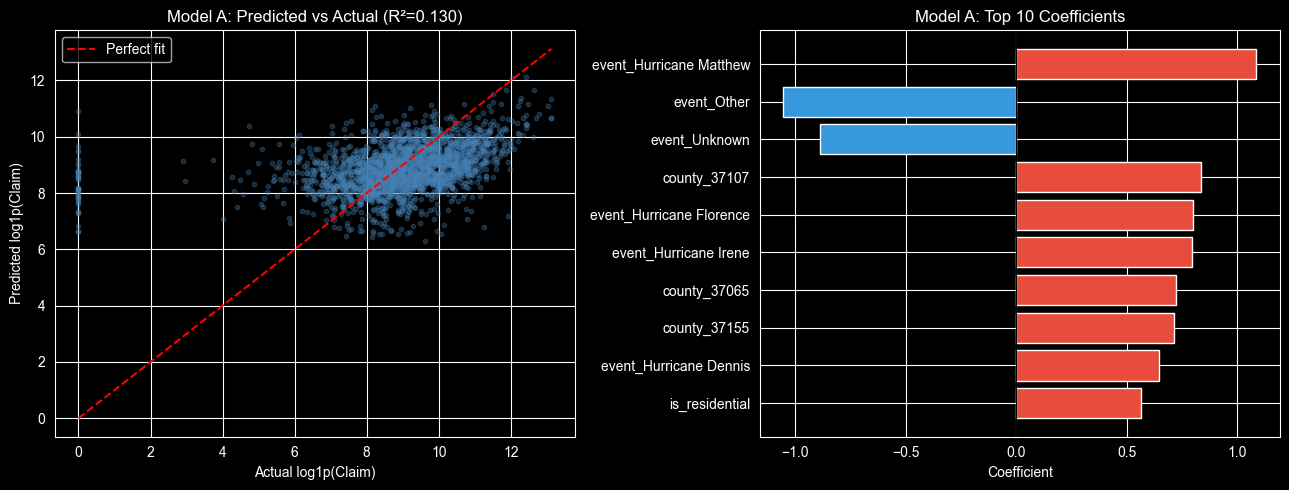

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(yA_test, yA_pred_test, alpha=0.3, s=10, color='steelblue')
lims = [min(yA_test.min(), yA_pred_test.min()), max(yA_test.max(), yA_pred_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual log1p(Claim)'); axes[0].set_ylabel('Predicted log1p(Claim)')
axes[0].set_title(f'Model A: Predicted vs Actual (R²={r2_test:.3f})'); axes[0].legend()

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_}).sort_values('Coefficient', key=abs, ascending=False)
top10 = coef_df.head(10)
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top10['Coefficient']]
axes[1].barh(top10['Feature'], top10['Coefficient'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Model A: Top 10 Coefficients'); axes[1].set_xlabel('Coefficient')
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

## Step 8: Model B — Logistic Regression
Target: high loss (1) vs low loss (0)

In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, yB_train)

yB_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
yB_pred = (yB_prob >= 0.5).astype(int)

print('=== Model B: Logistic Regression (threshold=0.5) ===')
print(f'Accuracy:  {accuracy_score(yB_test, yB_pred):.4f}')
print(f'Precision: {precision_score(yB_test, yB_pred):.4f}')
print(f'Recall:    {recall_score(yB_test, yB_pred):.4f}')
print(f'F1 Score:  {f1_score(yB_test, yB_pred):.4f}')

print('\n=== Threshold Sensitivity ===')
print(f'{"Threshold":<12} {"Accuracy":<12} {"Precision":<12} {"Recall":<12} {"F1":<10}')
print('-'*58)
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (yB_prob >= t).astype(int)
    print(f'{t:<12.1f} {accuracy_score(yB_test,p):<12.4f} {precision_score(yB_test,p,zero_division=0):<12.4f} {recall_score(yB_test,p,zero_division=0):<12.4f} {f1_score(yB_test,p,zero_division=0):<10.4f}')

=== Model B: Logistic Regression (threshold=0.5) ===
Accuracy:  0.6799
Precision: 0.6778
Recall:    0.6349
F1 Score:  0.6556

=== Threshold Sensitivity ===
Threshold    Accuracy     Precision    Recall       F1        
----------------------------------------------------------
0.3          0.5953       0.5454       0.9422       0.6909    
0.4          0.6411       0.5912       0.8174       0.6862    
0.5          0.6799       0.6778       0.6349       0.6556    
0.6          0.6636       0.7233       0.4844       0.5802    
0.7          0.6270       0.7793       0.3110       0.4446    


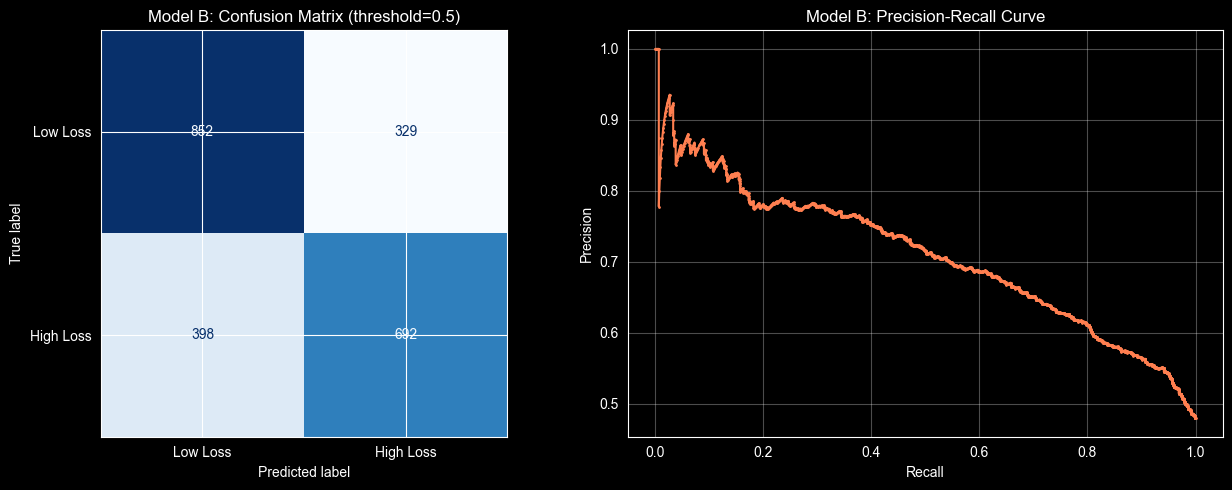

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(yB_test, yB_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low Loss','High Loss']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Model B: Confusion Matrix (threshold=0.5)')

prec_lr, rec_lr, _ = precision_recall_curve(yB_test, yB_prob)
axes[1].plot(rec_lr, prec_lr, marker='.', linewidth=1.5, color='coral', markersize=2)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Model B: Precision-Recall Curve'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Step 9: Linear vs Logistic — Coefficient Comparison

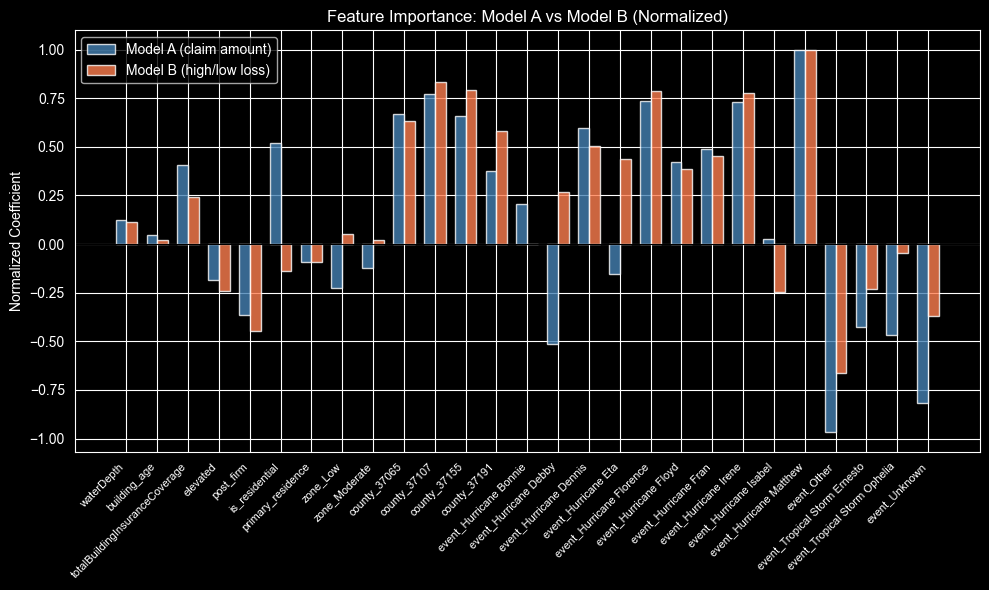


Full coefficient table:
                       Feature  ModelA_coef (log claim)  ModelB_coef (log odds)
                    waterDepth                     0.13                    0.15
                  building_age                     0.05                    0.03
totalBuildingInsuranceCoverage                     0.44                    0.32
                      elevated                    -0.20                   -0.31
                     post_firm                    -0.40                   -0.58
                is_residential                     0.57                   -0.18
             primary_residence                    -0.10                   -0.12
                      zone_Low                    -0.25                    0.07
                 zone_Moderate                    -0.13                    0.02
                  county_37065                     0.73                    0.83
                  county_37107                     0.84                    1.09
               

In [13]:
compare_df = pd.DataFrame({
    'Feature': X.columns,
    'ModelA_coef (log claim)': lr.coef_,
    'ModelB_coef (log odds)': log_reg.coef_[0]
})

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(compare_df))
width = 0.35
A_norm = compare_df['ModelA_coef (log claim)'] / compare_df['ModelA_coef (log claim)'].abs().max()
B_norm = compare_df['ModelB_coef (log odds)'] / compare_df['ModelB_coef (log odds)'].abs().max()
ax.bar(x_pos - width/2, A_norm, width, label='Model A (claim amount)', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, B_norm, width, label='Model B (high/low loss)', color='coral', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(compare_df['Feature'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Normalized Coefficient')
ax.set_title('Feature Importance: Model A vs Model B (Normalized)'); ax.legend()
plt.tight_layout(); plt.show()

print('\nFull coefficient table:')
print(compare_df.to_string(index=False))

## Step 10: Random Forest — Models C & D

Linear/Logistic Regression assumes features affect the target **independently and linearly**.  
Random Forest builds hundreds of decision trees and averages their predictions,  
capturing **non-linear relationships and interactions** between features (e.g. old building AND high flood zone AND Floyd = much higher loss).

Same X, same train/test split as Models A & B — direct apples-to-apples comparison.

In [14]:
# Model C: Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_scaled, yA_train)

rfA_pred_train = rf_reg.predict(X_train_scaled)
rfA_pred_test  = rf_reg.predict(X_test_scaled)

rfA_r2_train = r2_score(yA_train, rfA_pred_train)
rfA_r2_test  = r2_score(yA_test,  rfA_pred_test)
rfA_rmse     = np.sqrt(mean_squared_error(yA_test, rfA_pred_test))
rfA_rmse_usd = np.sqrt(mean_squared_error(np.expm1(yA_test), np.expm1(rfA_pred_test)))

print('=== Model C: Random Forest Regressor ===')
print(f'R²  (train): {rfA_r2_train:.4f}')
print(f'R²  (test):  {rfA_r2_test:.4f}')
print(f'RMSE (test): {rfA_rmse:.4f}  [log1p scale]')
print(f'RMSE (test): ~${rfA_rmse_usd:,.0f}  [USD scale]')
print()
print('=== vs Model A (Linear Regression) ===')
print(f'R²   improvement: {rfA_r2_test - r2_test:+.4f}')
print(f'RMSE improvement: ${rfA_rmse_usd - rmse_usd:+,.0f} USD')

=== Model C: Random Forest Regressor ===
R²  (train): 0.4425
R²  (test):  0.3685
RMSE (test): 1.4925  [log1p scale]
RMSE (test): ~$31,183  [USD scale]

=== vs Model A (Linear Regression) ===
R²   improvement: +0.2384
RMSE improvement: $-4,392 USD


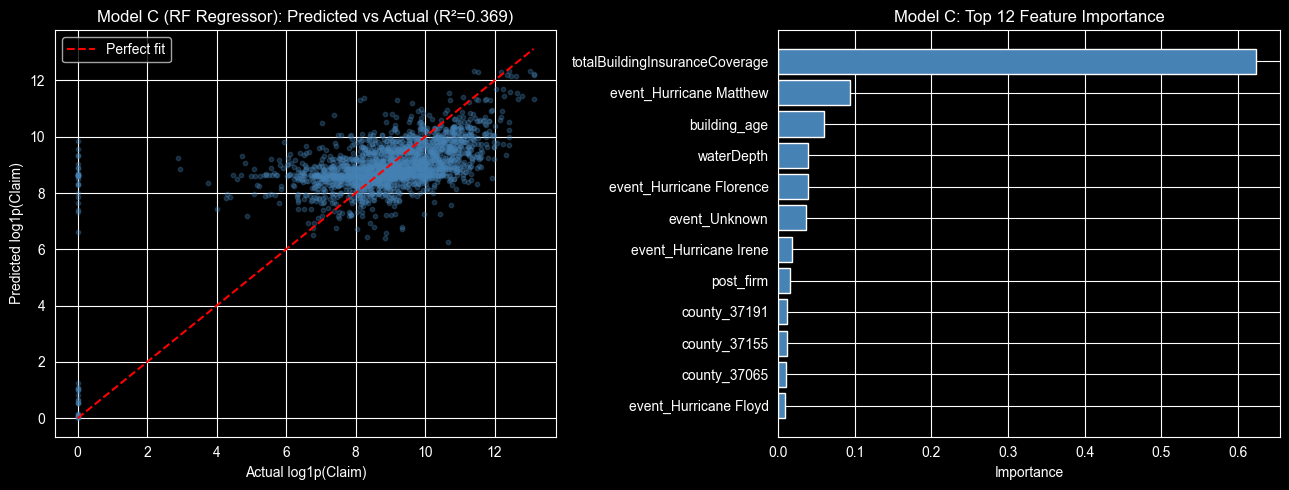

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(yA_test, rfA_pred_test, alpha=0.3, s=10, color='steelblue')
lims = [min(yA_test.min(), rfA_pred_test.min()), max(yA_test.max(), rfA_pred_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual log1p(Claim)'); axes[0].set_ylabel('Predicted log1p(Claim)')
axes[0].set_title(f'Model C (RF Regressor): Predicted vs Actual (R²={rfA_r2_test:.3f})')
axes[0].legend()

feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf_reg.feature_importances_}).sort_values('Importance', ascending=False)
axes[1].barh(feat_imp['Feature'].head(12), feat_imp['Importance'].head(12), color='steelblue')
axes[1].set_title('Model C: Top 12 Feature Importance')
axes[1].set_xlabel('Importance'); axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

In [16]:
# Model D: Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_scaled, yB_train)

rfB_prob = rf_clf.predict_proba(X_test_scaled)[:, 1]
rfB_pred = (rfB_prob >= 0.5).astype(int)

rfB_acc  = accuracy_score(yB_test, rfB_pred)
rfB_prec = precision_score(yB_test, rfB_pred)
rfB_rec  = recall_score(yB_test, rfB_pred)
rfB_f1   = f1_score(yB_test, rfB_pred)

print('=== Model D: Random Forest Classifier (threshold=0.5) ===')
print(f'Accuracy:  {rfB_acc:.4f}')
print(f'Precision: {rfB_prec:.4f}')
print(f'Recall:    {rfB_rec:.4f}')
print(f'F1 Score:  {rfB_f1:.4f}')
print()
print('=== vs Model B (Logistic Regression) ===')
print(f'Accuracy improvement: {rfB_acc - accuracy_score(yB_test, yB_pred):+.4f}')
print(f'F1 improvement:       {rfB_f1 - f1_score(yB_test, yB_pred):+.4f}')

=== Model D: Random Forest Classifier (threshold=0.5) ===
Accuracy:  0.7028
Precision: 0.7036
Recall:    0.6578
F1 Score:  0.6799

=== vs Model B (Logistic Regression) ===
Accuracy improvement: +0.0229
F1 improvement:       +0.0243


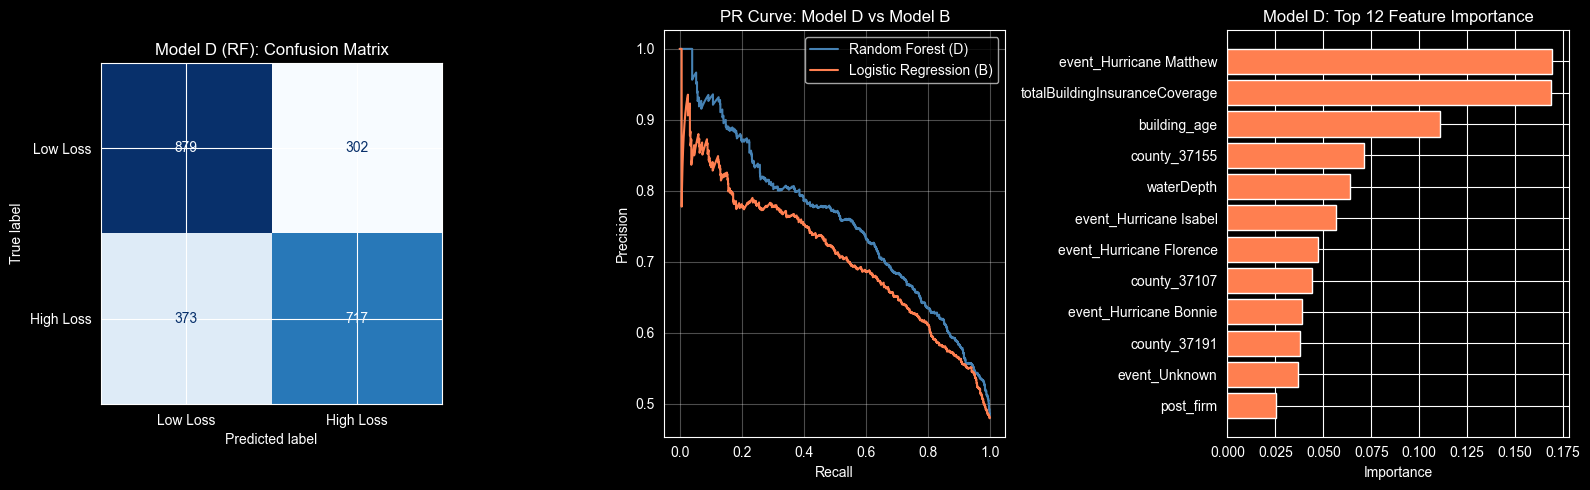

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cm_rf = confusion_matrix(yB_test, rfB_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['Low Loss','High Loss']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Model D (RF): Confusion Matrix')

prec_rf, rec_rf, _ = precision_recall_curve(yB_test, rfB_prob)
axes[1].plot(rec_rf, prec_rf, color='steelblue', linewidth=1.5, label='Random Forest (D)')
axes[1].plot(rec_lr, prec_lr, color='coral',     linewidth=1.5, label='Logistic Regression (B)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve: Model D vs Model B'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

feat_imp_clf = pd.DataFrame({'Feature': X.columns, 'Importance': rf_clf.feature_importances_}).sort_values('Importance', ascending=False)
axes[2].barh(feat_imp_clf['Feature'].head(12), feat_imp_clf['Importance'].head(12), color='coral')
axes[2].set_title('Model D: Top 12 Feature Importance')
axes[2].set_xlabel('Importance'); axes[2].invert_yaxis()

plt.tight_layout(); plt.show()

## Step 11: Final Summary — All Four Models

In [18]:
print('=' * 60)
print('FINAL MODEL COMPARISON')
print('=' * 60)
print(f'{"Model":<6} {"Type":<25} {"Metric 1":<20} {"Metric 2"}')
print('-' * 60)
print(f'{"A":<6} {"Linear Regression":<25} {f"R²={r2_test:.4f}":<20} {f"RMSE=${rmse_usd:,.0f}"}')
print(f'{"B":<6} {"Logistic Regression":<25} {f"Acc={accuracy_score(yB_test,yB_pred):.4f}":<20} {f"F1={f1_score(yB_test,yB_pred):.4f}"}')
print(f'{"C":<6} {"RF Regressor":<25} {f"R²={rfA_r2_test:.4f}":<20} {f"RMSE=${rfA_rmse_usd:,.0f}"}')
print(f'{"D":<6} {"RF Classifier":<25} {f"Acc={rfB_acc:.4f}":<20} {f"F1={rfB_f1:.4f}"}')
print('=' * 60)

FINAL MODEL COMPARISON
Model  Type                      Metric 1             Metric 2
------------------------------------------------------------
A      Linear Regression         R²=0.1301            RMSE=$35,576
B      Logistic Regression       Acc=0.6799           F1=0.6556
C      RF Regressor              R²=0.3685            RMSE=$31,183
D      RF Classifier             Acc=0.7028           F1=0.6799


## Limitations

- FEMA coordinates privacy-masked to 0.1° (~11km) — precise spatial joins not possible
- `elevationDifference` excluded (59% missing)
- Claims data covers insured properties only — uninsured losses not captured
- Repeated claims per property not deduplicated (each hurricane = separate row)
- Median split for Model B/D is data-driven, not domain-defined